<a href="https://colab.research.google.com/github/mohany606/RFM-Analysis-task-NTI/blob/main/task_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding
This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

**Important Additional Variable Information**


  > **InvoiceNo**: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.

  >  **StockCode**: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.

  > **Quantity**: The quantities of each product (item) per transaction. Numeric.

  > **UnitPrice**: Unit price. Numeric, Product price per unit in sterling.

  > **CustomerID**: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.


# Exploratory Data Analysis (EDA) & Feature Engineering


In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [54]:
df = pd.read_excel('/content/Online Retail.xlsx')

In [55]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


The big percentage of the nulls in the CustomerID referes to not signed in users

 dealing with it the best way is **unfortunately droping** them because the target is **RFM analysis**

In [57]:
df.dropna(subset=['CustomerID'],inplace=True)

In [58]:
df_copy = df.copy()

In [59]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df.drop(columns='InvoiceDate',inplace = True)
display(df[[ 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay']].head())

,InvoiceYear,InvoiceMonth,InvoiceDay
0,2010,12,1
1,2010,12,1
2,2010,12,1
3,2010,12,1
4,2010,12,1


In [60]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [61]:
df['IsCancellation'] = (df['Quantity'] < 0) | (df['InvoiceNo'].astype(str).str.startswith('C', na=False))

In [62]:
sales_df = df[~df['IsCancellation'] & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
returns_df = df[df['IsCancellation']].copy()


# we need that feature (CustomerID) for the RFM feature Extraction , so i won't encode it

In [63]:
df['CustomerID'].nunique()

4372

In [64]:
df['StockCode'].nunique()

3684

In [65]:
df.describe()

,Quantity,UnitPrice,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,Hour,Revenue
count,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570,2010.934002,7.605947,15.036128,12.737472,20.401854
std,248.693370,69.315162,1713.600303,0.248279,3.418942,8.653730,2.284952,427.591718
min,-80995.000000,0.000000,12346.000000,2010.000000,1.000000,1.000000,6.000000,-168469.600000
25%,2.000000,1.250000,13953.000000,2011.000000,5.000000,7.000000,11.000000,4.200000
50%,5.000000,1.950000,15152.000000,2011.000000,8.000000,15.000000,13.000000,11.100000
75%,12.000000,3.750000,16791.000000,2011.000000,11.000000,22.000000,14.000000,19.500000
max,80995.000000,38970.000000,18287.000000,2011.000000,12.000000,31.000000,20.000000,168469.600000


# Insights and visuals

# **1. Top Products (Units Sold vs. Revenue):**

/tmp/ipykernel_1313/1028583855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_units, y=prod_col, x='Quantity', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1313/1028583855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rev, y=prod_col, x='Revenue', ax=axes[1], palette='Greens_r')


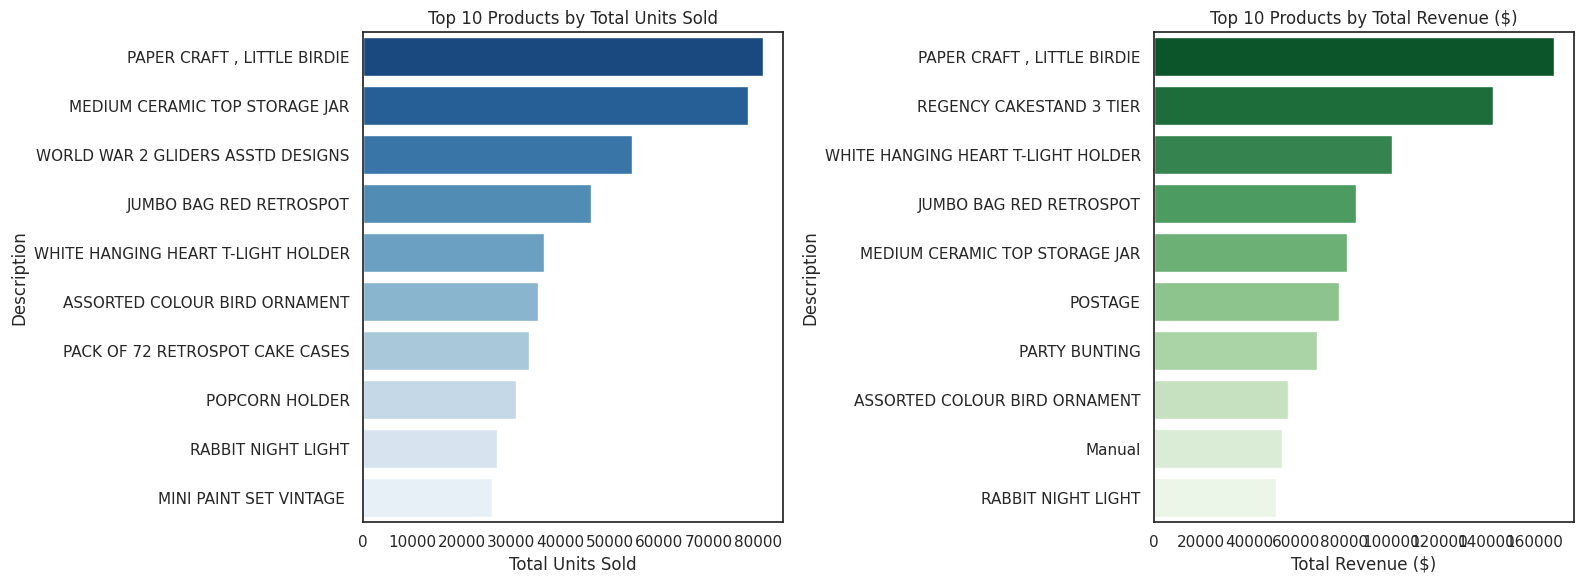

In [66]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Identify Product column (Description if available, else StockCode)
prod_col = 'Description' if 'Description' in sales_df.columns else 'StockCode'

# Top by Units Sold
top_units = sales_df.groupby(prod_col)['Quantity'].sum().nlargest(10).reset_index()
sns.barplot(data=top_units, y=prod_col, x='Quantity', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Products by Total Units Sold')
axes[0].set_xlabel('Total Units Sold')

# Top by Revenue
top_rev = sales_df.groupby(prod_col)['Revenue'].sum().nlargest(10).reset_index()
sns.barplot(data=top_rev, y=prod_col, x='Revenue', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Products by Total Revenue ($)')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

# **2. Top Customers (Revenue & Orders)**

/tmp/ipykernel_1313/2254537646.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cust_rev, x='TotalRevenue', y='CustomerID', ax=axes[0], palette='Purples_r')
/tmp/ipykernel_1313/2254537646.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cust_orders, x='TotalOrders', y='CustomerID', ax=axes[1], palette='Oranges_r')


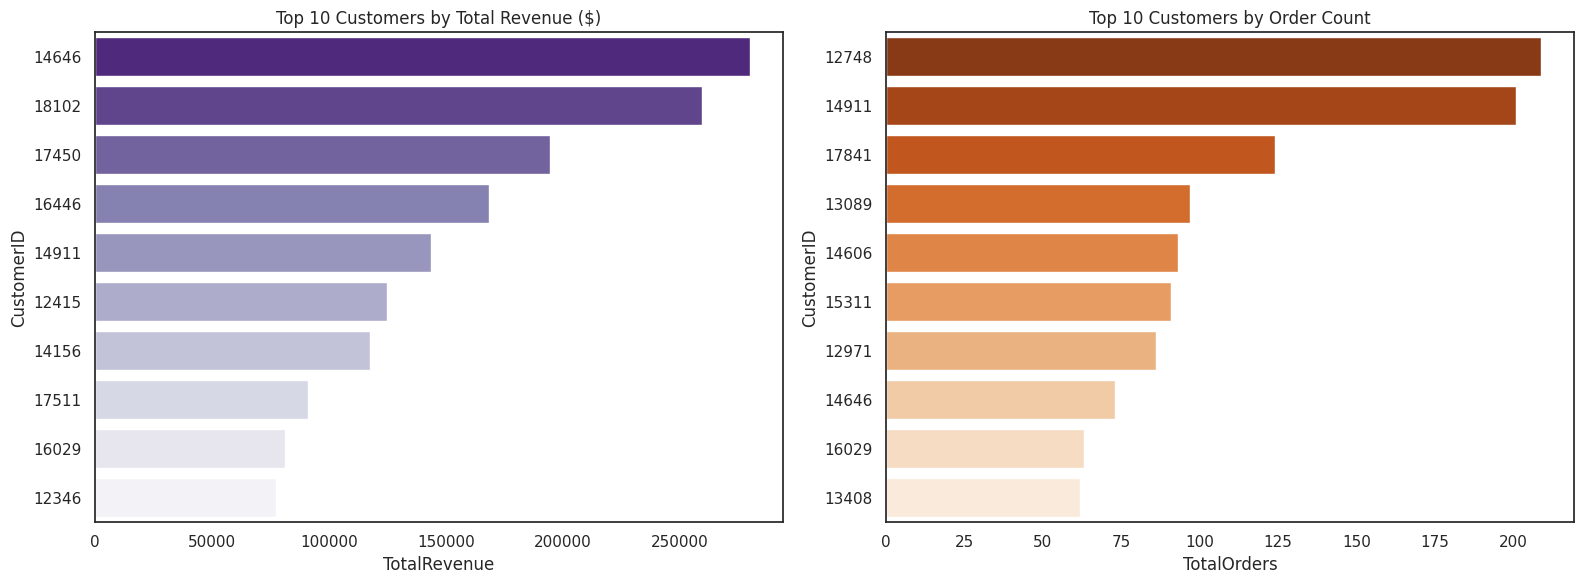

In [67]:
# @title
# Filter out missing CustomerIDs for customer-level queries
cust_df = sales_df.dropna(subset=['CustomerID']).copy()
cust_df['CustomerID'] = cust_df['CustomerID'].astype(int).astype(str)

cust_summary = cust_df.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Customers by Revenue
top_cust_rev = cust_summary.nlargest(10, 'TotalRevenue')
sns.barplot(data=top_cust_rev, x='TotalRevenue', y='CustomerID', ax=axes[0], palette='Purples_r')
axes[0].set_title('Top 10 Customers by Total Revenue ($)')

# Top Customers by Order Count
top_cust_orders = cust_summary.nlargest(10, 'TotalOrders')
sns.barplot(data=top_cust_orders, x='TotalOrders', y='CustomerID', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Customers by Order Count')

plt.tight_layout()
plt.show()

# **3. Revenue Trends & Seasonal Patterns**

In [68]:
sales_df['YearMonth'] = df_copy['InvoiceDate'].dt.to_period('M').astype(str)

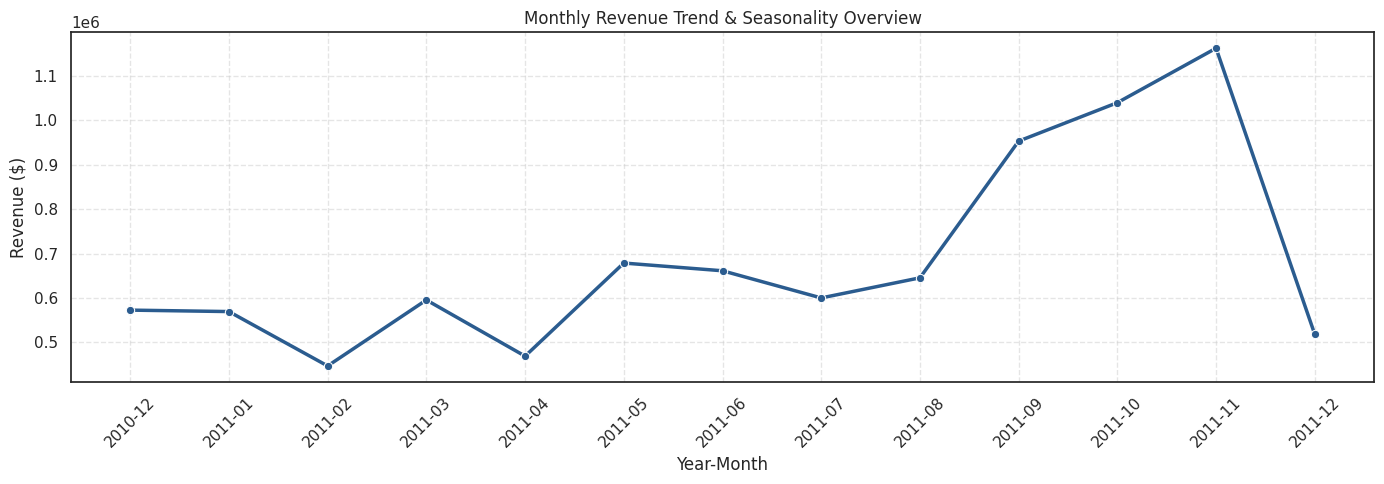

In [69]:
# @title
plt.figure(figsize=(14, 5))

# Monthly Revenue Trend
monthly_rev = sales_df.groupby('YearMonth')['Revenue'].sum().reset_index()
sns.lineplot(data=monthly_rev, x='YearMonth', y='Revenue', marker='o', color='#2b5c8f', linewidth=2.5)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend & Seasonality Overview')
plt.ylabel('Revenue ($)')
plt.xlabel('Year-Month')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **4. Peak Activity (Months, Weekdays, and Hours)**

/tmp/ipykernel_1313/675405069.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x='InvoiceMonth', y='Revenue', ax=axes[0], palette='crest')
/tmp/ipykernel_1313/675405069.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='Weekday', y='Revenue', ax=axes[1], palette='viridis')


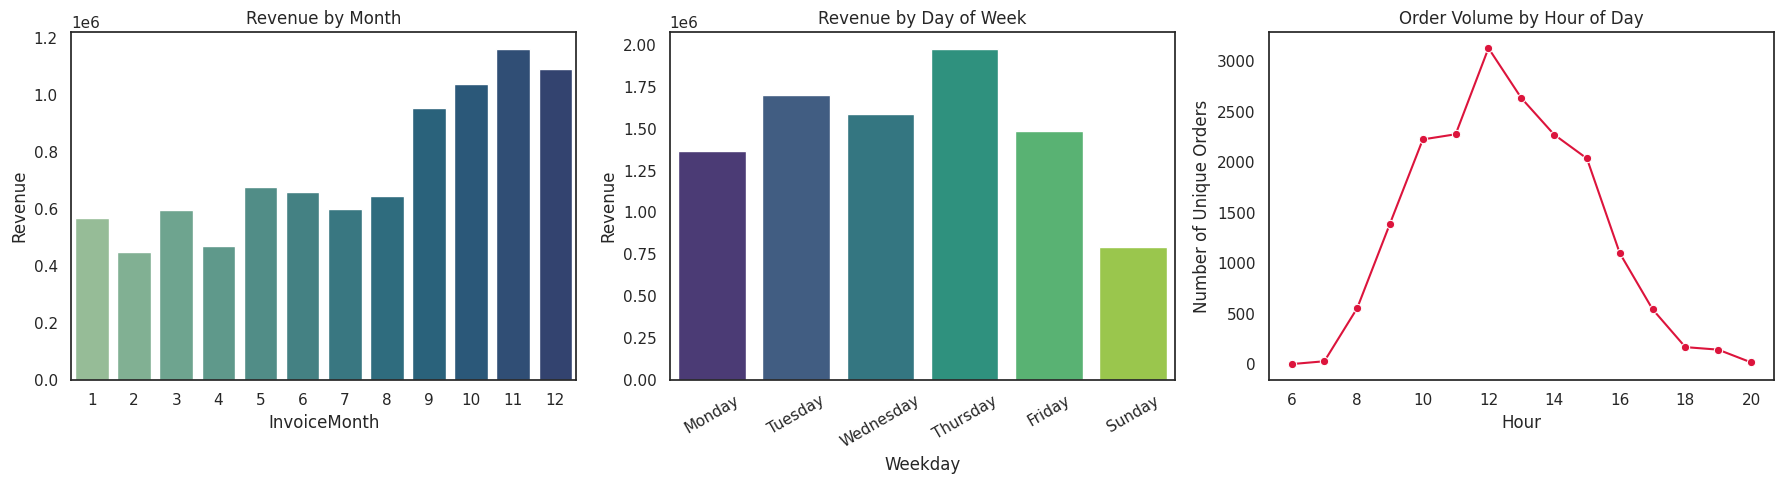

In [70]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By Month
monthly_sales = sales_df.groupby('InvoiceMonth')['Revenue'].sum().reset_index()
sns.barplot(data=monthly_sales, x='InvoiceMonth', y='Revenue', ax=axes[0], palette='crest')
axes[0].set_title('Revenue by Month')

# By Weekday (if datetime available)
if 'Weekday' in sales_df.columns:
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_sales = sales_df.groupby('Weekday')['Revenue'].sum().reindex(days_order).dropna().reset_index()
    sns.barplot(data=weekday_sales, x='Weekday', y='Revenue', ax=axes[1], palette='viridis')
    axes[1].set_title('Revenue by Day of Week')
    axes[1].tick_params(axis='x', rotation=30)

# By Hour (if datetime available)
if 'Hour' in sales_df.columns:
    hourly_orders = sales_df.groupby('Hour')['InvoiceNo'].nunique().reset_index()
    sns.lineplot(data=hourly_orders, x='Hour', y='InvoiceNo', ax=axes[2], marker='o', color='crimson')
    axes[2].set_title('Order Volume by Hour of Day')
    axes[2].set_ylabel('Number of Unique Orders')

plt.tight_layout()
plt.show()

# **5. Country Analysis (Customers, Orders, Revenue)**

/tmp/ipykernel_1313/2695517653.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Revenue', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1313/2695517653.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Orders', ax=axes[1], palette='Greens_r')
/tmp/ipykernel_1313/2695517653.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Customers', ax=axes[2], palette='Purples_r')


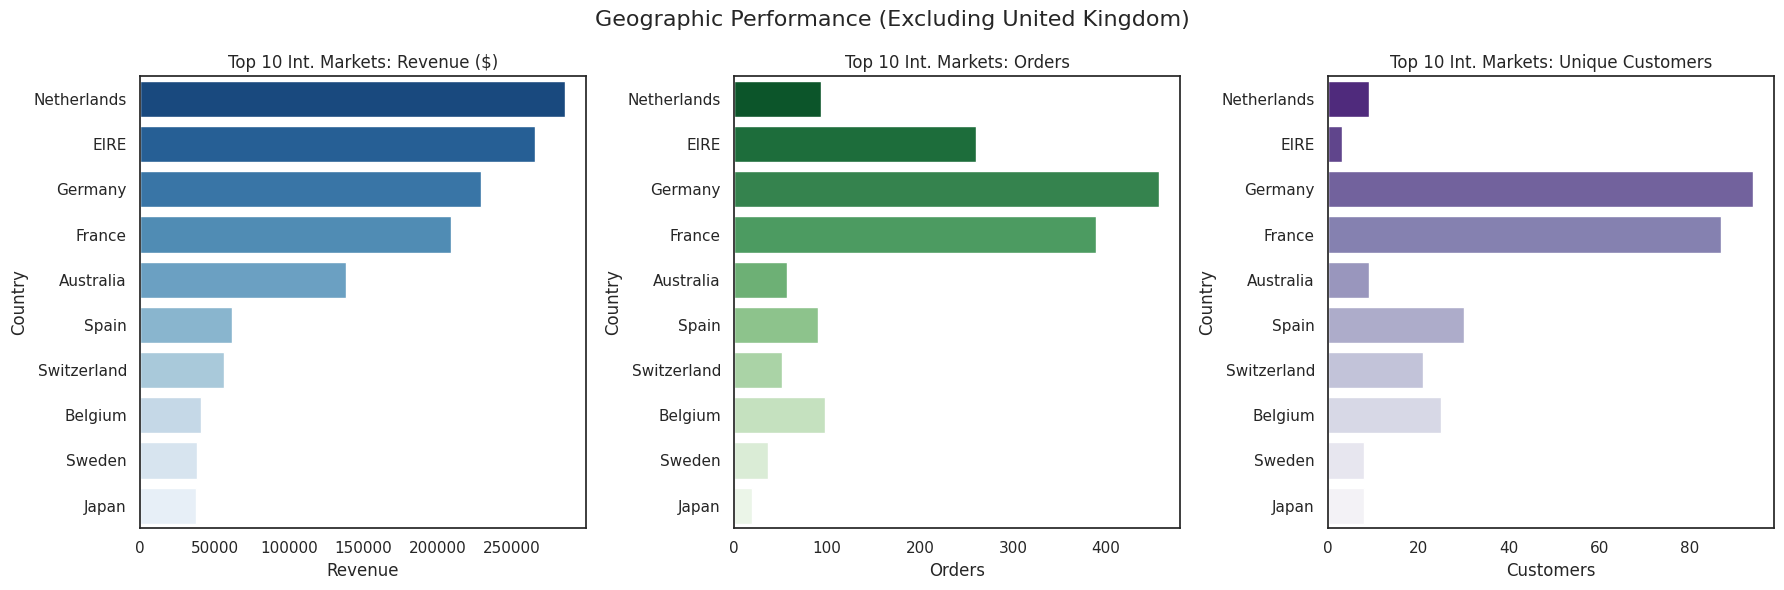

In [71]:
# @title
# Group by country
country_metrics = sales_df.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique')
).reset_index()

# Exclude UK to highlight international markets (UK dominates ~90% of data)
country_ex_uk = country_metrics[country_metrics['Country'] != 'United Kingdom'].nlargest(10, 'Revenue')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=country_ex_uk, y='Country', x='Revenue', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Int. Markets: Revenue ($)')

sns.barplot(data=country_ex_uk, y='Country', x='Orders', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Int. Markets: Orders')

sns.barplot(data=country_ex_uk, y='Country', x='Customers', ax=axes[2], palette='Purples_r')
axes[2].set_title('Top 10 Int. Markets: Unique Customers')

plt.suptitle('Geographic Performance (Excluding United Kingdom)', fontsize=16)
plt.tight_layout()
plt.show()

# **6. Top 5 products in top 5 international markets in revenue**

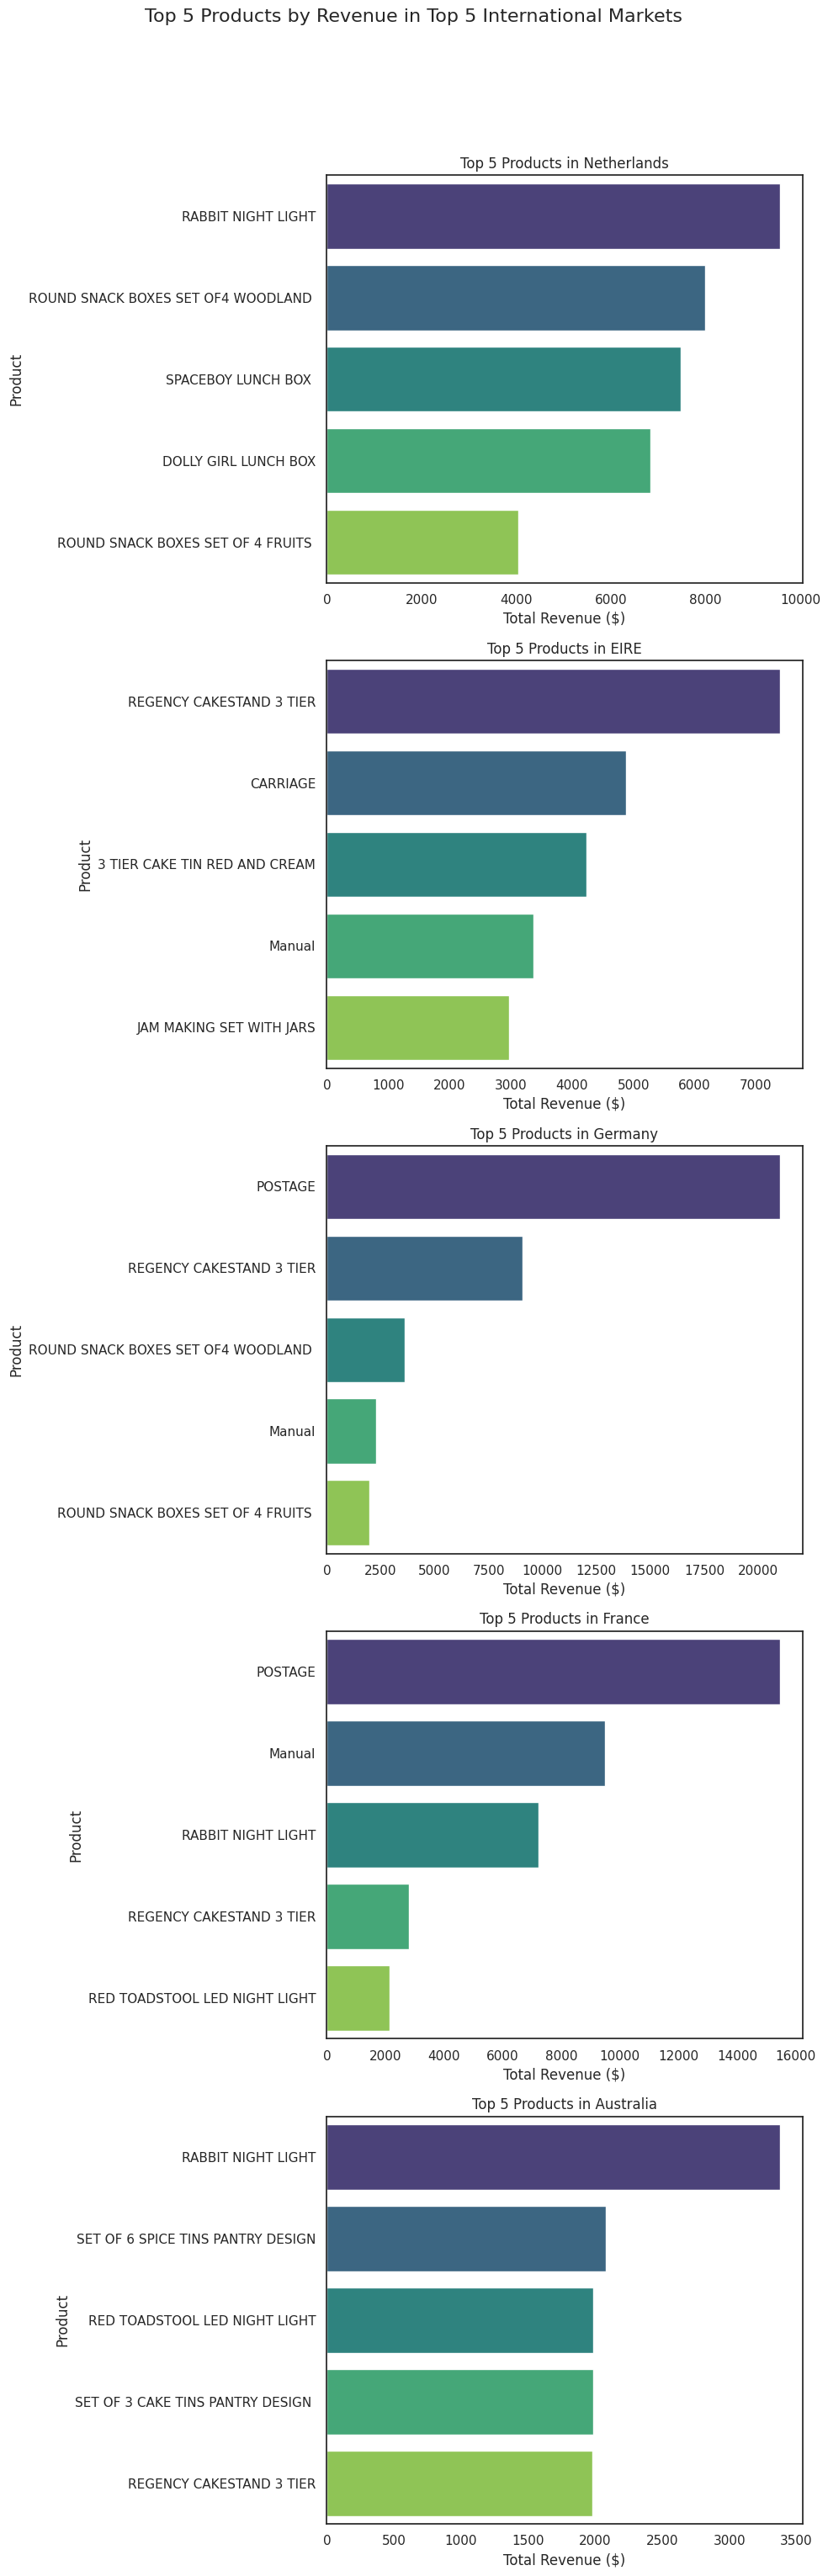

In [72]:
prod_col = 'Description' if 'Description' in sales_df.columns else 'StockCode'

top_5_countries = country_ex_uk['Country'].head(5).tolist()

fig, axes = plt.subplots(nrows=len(top_5_countries), ncols=1, figsize=(10, 6 * len(top_5_countries)))
fig.suptitle('Top 5 Products by Revenue in Top 5 International Markets', fontsize=16, y=1.02)

for i, country in enumerate(top_5_countries):
    country_df = sales_df[sales_df['Country'] == country]
    top_products_country = country_df.groupby(prod_col)['Revenue'].sum().nlargest(5).reset_index()

    sns.barplot(data=top_products_country, y=prod_col, x='Revenue', ax=axes[i], palette='viridis', hue=prod_col, legend=False)
    axes[i].set_title(f'Top 5 Products in {country}')
    axes[i].set_xlabel('Total Revenue ($)')
    axes[i].set_ylabel('Product')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# **7. Cancellations & Returns Analysis**

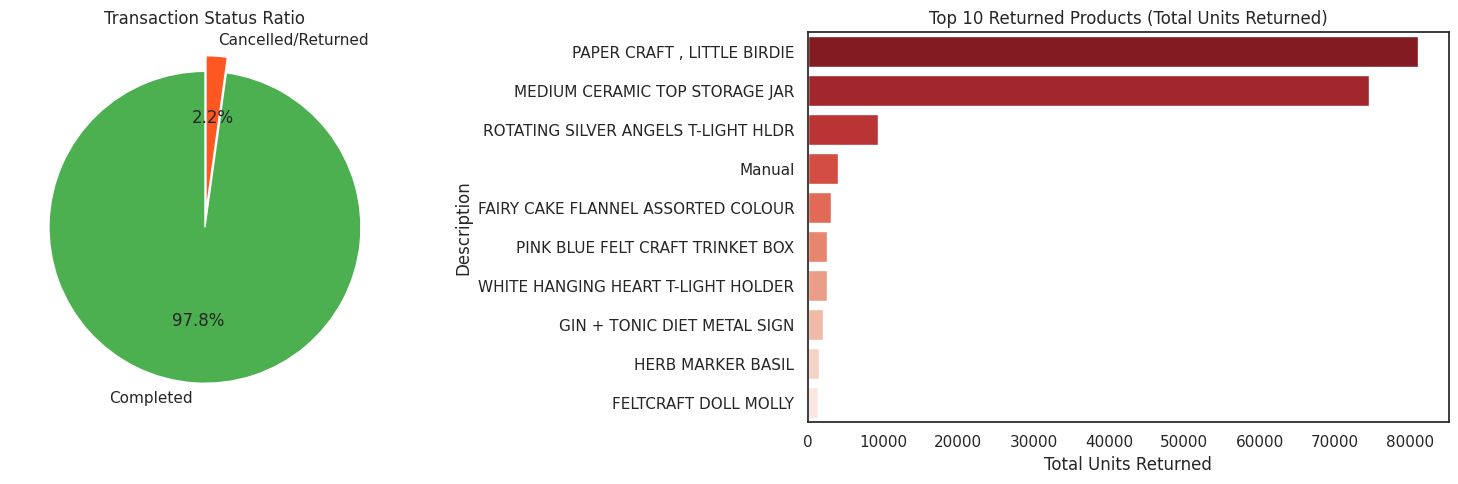

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Overall Return Proportion
cancellation_counts = df['IsCancellation'].value_counts(normalize=True) * 100
axes[0].pie(cancellation_counts, labels=['Completed', 'Cancelled/Returned'],
            autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], explode=(0, 0.1), startangle=90)
axes[0].set_title('Transaction Status Ratio')

# 2. Top Returned Products by Frequency
top_returns = returns_df.assign(AbsQuantity=returns_df['Quantity'].abs()).groupby(prod_col)['AbsQuantity'].sum().nlargest(10).reset_index()
sns.barplot(data=top_returns, y=prod_col, x='AbsQuantity', ax=axes[1], palette='Reds_r', hue=prod_col, legend=False)
axes[1].set_title('Top 10 Returned Products (Total Units Returned)')
axes[1].set_xlabel('Total Units Returned')

plt.tight_layout()
plt.show()

# **RFM Customer Segmentation Matrix**

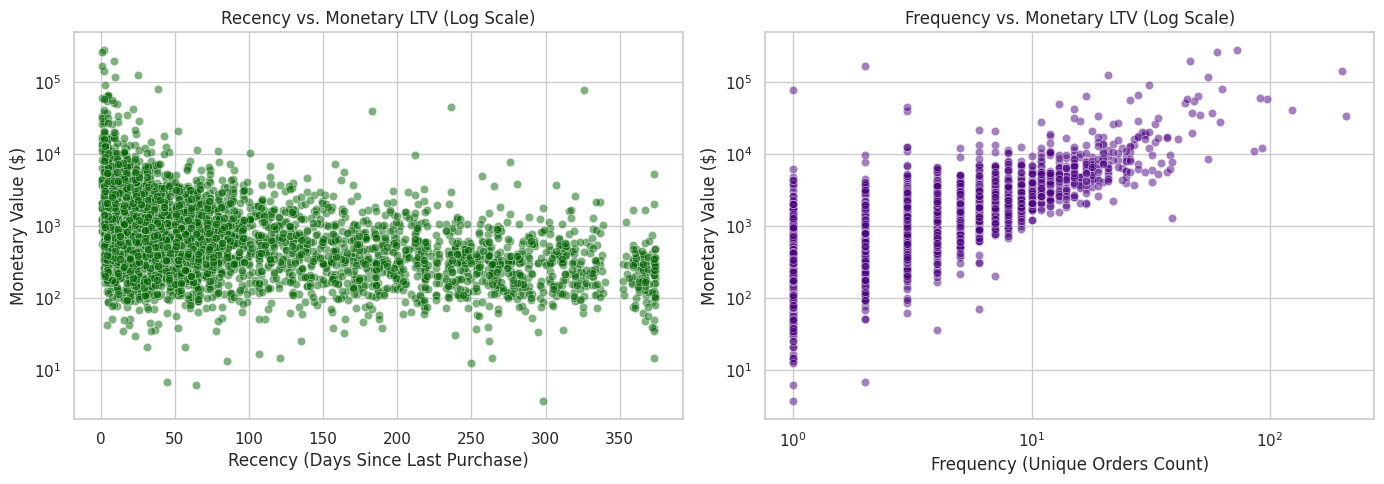

In [74]:


# Set visual style
sns.set_theme(style="whitegrid")

# 1. Reconstruct InvoiceDate if missing
if 'InvoiceDate' not in df.columns:
    df['InvoiceDate'] = pd.to_datetime(
        df['InvoiceYear'].astype(str) + '-' +
        df['InvoiceMonth'].astype(str).str.zfill(2) + '-' +
        df['InvoiceDay'].astype(str).str.zfill(2)
    )

# Filter valid completed sales and valid CustomerIDs
sales_df = df[~df['IsCancellation'] & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
cust_df = sales_df.dropna(subset=['CustomerID']).copy()
cust_df['CustomerID'] = cust_df['CustomerID'].astype(int).astype(str)

# 3. Calculate RFM Metrics
ref_date = cust_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = cust_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Exclude non-positive monetary values if any exist
rfm = rfm[rfm['Monetary'] > 0]

# 4. Plot RFM Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', ax=axes[0], alpha=0.5, color='darkgreen')
axes[0].set_yscale('log')
axes[0].set_title('Recency vs. Monetary LTV (Log Scale)')
axes[0].set_xlabel('Recency (Days Since Last Purchase)')
axes[0].set_ylabel('Monetary Value ($)')

# Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', ax=axes[1], alpha=0.5, color='indigo')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Frequency vs. Monetary LTV (Log Scale)')
axes[1].set_xlabel('Frequency (Unique Orders Count)')
axes[1].set_ylabel('Monetary Value ($)')

plt.tight_layout()
plt.show()

# **Compute RFM Quantiles & Segment Customers**

In [75]:

# Set visual style
sns.set_theme(style="white", palette="muted")
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency often has identical values (e.g. lots of 1-order customers), so drop duplicates
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine scores into an overall RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 2. Map Scores into Actionable Business Segments
def assign_segment(df):
    r = df['R_Score']
    f = df['F_Score']
    m = df['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Visitors / New'
    elif r == 3 and f <= 2:
        return 'Promising / Potential'
    elif r == 3 and f >= 3:
        return 'Need Attention'
    elif r == 2 and f >= 3:
        return 'About to Sleep'
    elif r <= 2 and f >= 4:
        return 'At Risk (High Value)'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Hibernating / Other'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("--- RFM Customer Segmentation Summary ---")
print(rfm['Segment'].value_counts())

--- RFM Customer Segmentation Summary ---
Segment
Lost Customers           1071
Champions                 953
Loyal Customers           760
About to Sleep            457
Promising / Potential     352
Recent Visitors / New     312
Hibernating / Other       291
Need Attention             84
At Risk (High Value)       58
Name: count, dtype: int64


# **Visualizing the Segments**

/tmp/ipykernel_1313/2967804500.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, y='Segment', x='Total_Revenue', ax=axes[0], palette='Greens_r')
/tmp/ipykernel_1313/2967804500.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, y='Segment', x='Customer_Count', ax=axes[1], palette='Blues_r')


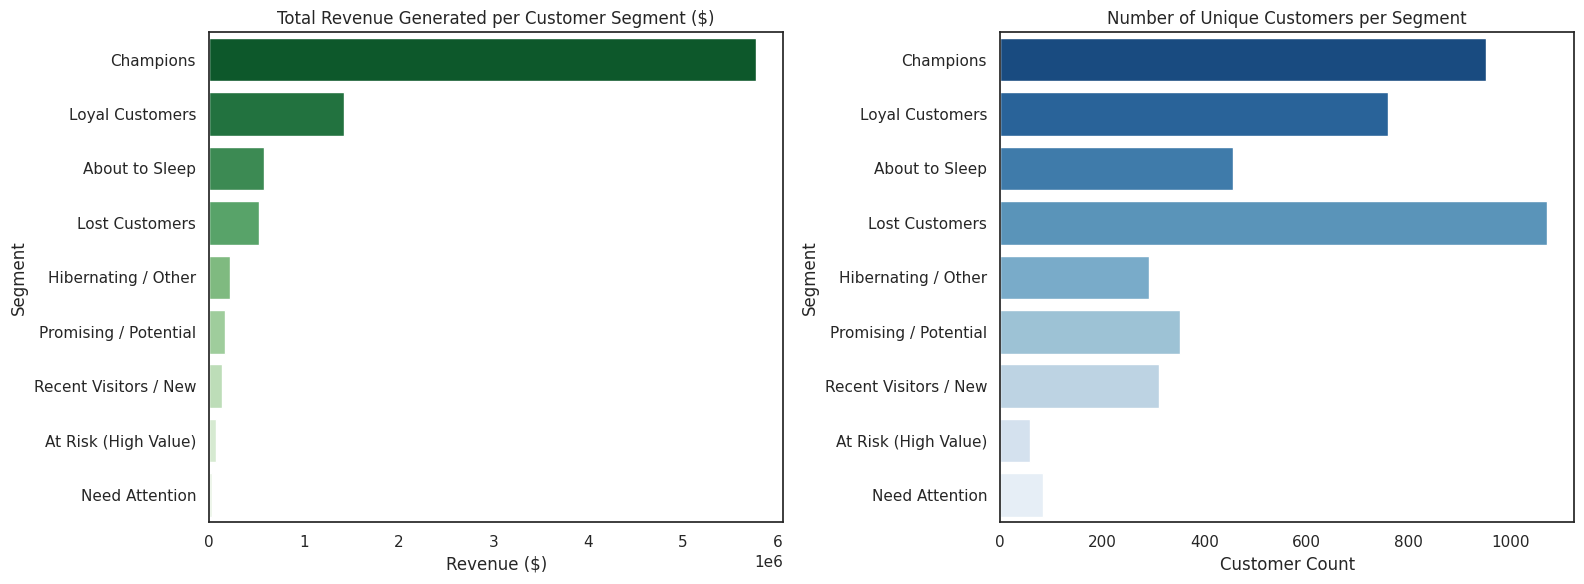

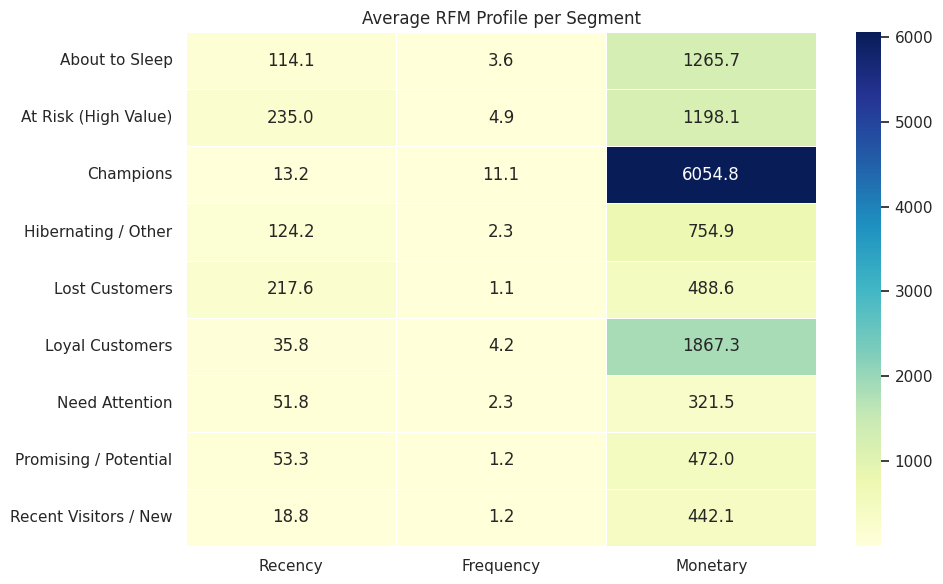

In [76]:
# Aggregate average values per segment
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

# Percentage of total revenue per segment
total_rev = segment_summary['Total_Revenue'].sum()
segment_summary['Revenue_Share_%'] = (segment_summary['Total_Revenue'] / total_rev) * 100

# Plot 1: Segment Distribution by Revenue & Count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=segment_summary, y='Segment', x='Total_Revenue', ax=axes[0], palette='Greens_r')
axes[0].set_title('Total Revenue Generated per Customer Segment ($)')
axes[0].set_xlabel('Revenue ($)')

sns.barplot(data=segment_summary, y='Segment', x='Customer_Count', ax=axes[1], palette='Blues_r')
axes[1].set_title('Number of Unique Customers per Segment')
axes[1].set_xlabel('Customer Count')

plt.tight_layout()
plt.show()

# Plot 2: Heatmap of Average RFM Metrics by Segment
heatmap_data = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title('Average RFM Profile per Segment')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Preprocessing for the unsupervised models



# Applying K-fold target encoding for the feature of StockCode

In [77]:
overall_mean_unit_price = df['UnitPrice'].mean()
df.reset_index(drop=True, inplace=True)
df['StockCode_TargetEncoded'] = np.nan

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get the column index for 'StockCode_TargetEncoded' for iloc assignment
df_col_idx = df.columns.get_loc('StockCode_TargetEncoded')

for train_index, val_index in kf.split(df):
    # Use iloc for slicing as df now has a RangeIndex and KFold returns integer positions
    X_train, X_val = df.iloc[train_index], df.iloc[val_index]
    target_mean_map = X_train.groupby('StockCode')['UnitPrice'].mean()
    df.iloc[val_index, df_col_idx] = X_val['StockCode'].map(target_mean_map).fillna(overall_mean_unit_price)

print("DataFrame with K-fold Target Encoded StockCode:")
display(df[['StockCode', 'UnitPrice', 'StockCode_TargetEncoded']].head())
df.drop(columns=['StockCode'],inplace=True)

DataFrame with K-fold Target Encoded StockCode:


,StockCode,UnitPrice,StockCode_TargetEncoded
0,85123A,2.55,2.891525
1,71053,3.39,3.764587
2,84406B,2.75,3.838137
3,84029G,3.39,4.014338
4,84029E,3.39,4.063216


In [78]:
df['IsUnitedKingdom'] = df['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

In [79]:
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler

# 1. Frequency Encoding (Proportion / Relative Frequency)
country_freq = df['Country'].value_counts(normalize=True)
df['Country_Freq'] = df['Country'].map(country_freq)

# 2. Log Transformation (Compresses the extreme right skew of the UK)
df['Country_Freq_Log'] = np.log1p(df['Country_Freq'] * 100)

# 3. Standard or Robust Scaling (Zero mean, unit variance)
scaler = StandardScaler()
df['Country_Freq_Scaled'] = scaler.fit_transform(df[['Country_Freq_Log']])

In [80]:
df.drop(columns=['Country_Freq','Country_Freq_Scaled'],inplace=True)

In [84]:
df.head()

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,Hour,Weekday,Revenue,IsCancellation,InvoiceDate,StockCode_TargetEncoded,IsUnitedKingdom,Country_Freq_Log
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,1,8,Wednesday,15.30,False,2010-12-01,2.891525,1,4.499264
1,536365,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34,False,2010-12-01,3.764587,1,4.499264
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,1,8,Wednesday,22.00,False,2010-12-01,3.838137,1,4.499264
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34,False,2010-12-01,4.014338,1,4.499264
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34,False,2010-12-01,4.063216,1,4.499264


In [85]:
df.drop(columns=['Weekday','InvoiceDate','Description'],inplace=True)

In [88]:
df.head()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,Hour,Revenue,IsCancellation,StockCode_TargetEncoded,IsUnitedKingdom,Country_Freq_Log
0,536365,6,2.55,17850.0,United Kingdom,2010,12,1,8,15.30,0,2.891525,1,4.499264
1,536365,6,3.39,17850.0,United Kingdom,2010,12,1,8,20.34,0,3.764587,1,4.499264
2,536365,8,2.75,17850.0,United Kingdom,2010,12,1,8,22.00,0,3.838137,1,4.499264
3,536365,6,3.39,17850.0,United Kingdom,2010,12,1,8,20.34,0,4.014338,1,4.499264
4,536365,6,3.39,17850.0,United Kingdom,2010,12,1,8,20.34,0,4.063216,1,4.499264


In [87]:
df['IsCancellation'] = df['IsCancellation'].astype(int)

Scaled RFM features head:


,Recency,Frequency,Monetary
0,2.204409,-0.25,56.492434
1,-0.384770,1.25,2.684374
2,0.200401,0.50,0.829014
3,-0.256513,-0.25,0.799708
4,2.084168,-0.25,-0.251110



--- K-Means Clustering ---


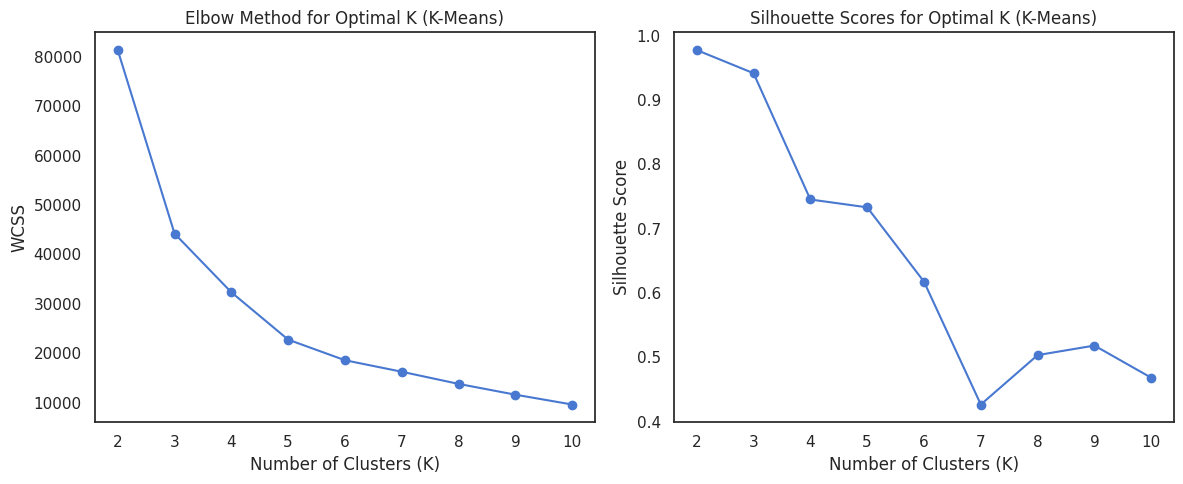

K-Means Silhouette Score (K=4): 0.745


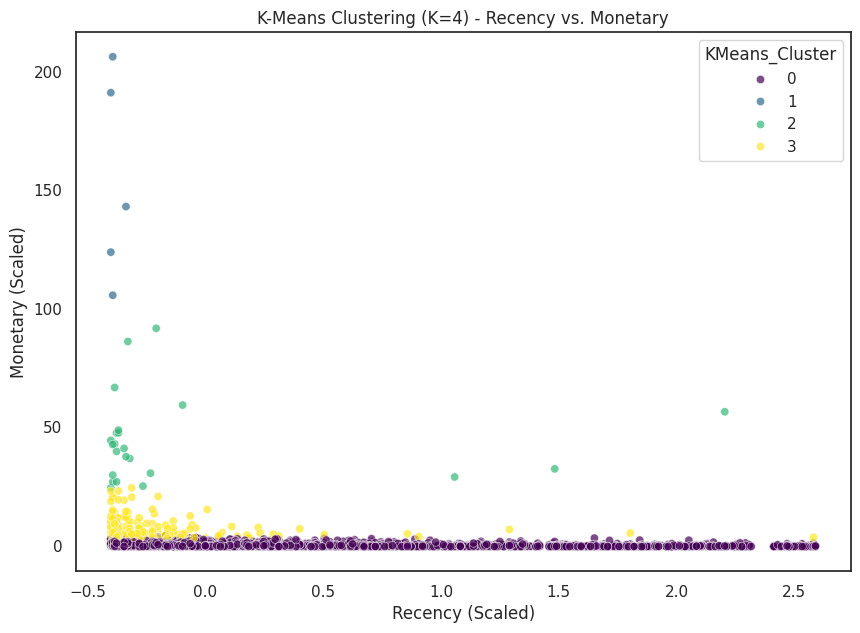


--- K-Median Clustering ---
Note: K-Median clustering is not directly available in scikit-learn.
It uses the Manhattan distance (L1 norm) for centroid calculation, making it more robust to outliers than K-Means.
Implementing it would typically require a specialized library (e.g., 'scikit-learn-extra') or a custom implementation.
For this demonstration, we will proceed with other standard scikit-learn models.

--- DBSCAN Clustering ---
DBSCAN Silhouette Score (excluding noise): 0.740


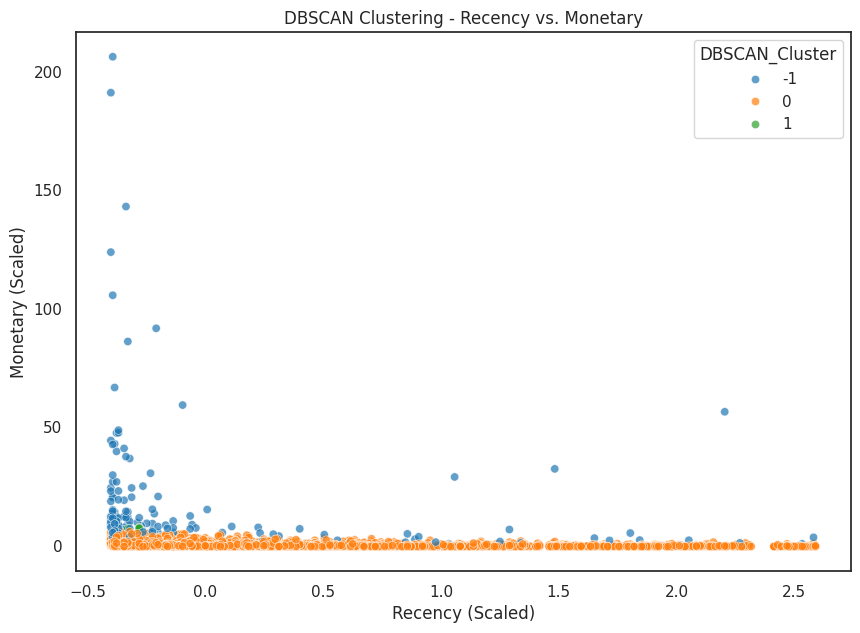

DBSCAN found 3 clusters (including noise as -1).

--- Hierarchical Clustering ---
Hierarchical Clustering Silhouette Score (K=4): 0.910


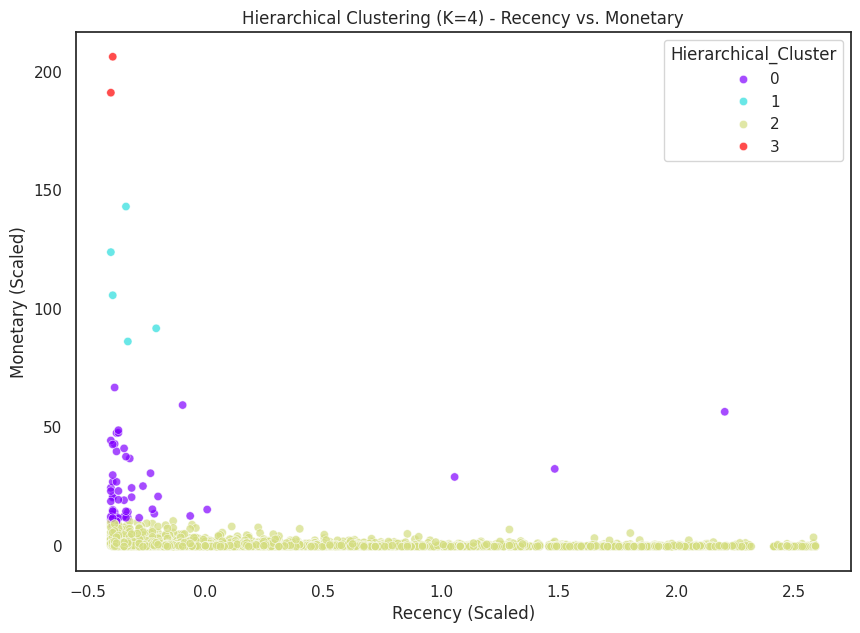


--- Comparative Evaluation of Clustering Models ---


/tmp/ipykernel_1313/3755549724.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Silhouette Score', data=silhouette_df, palette='cubehelix')


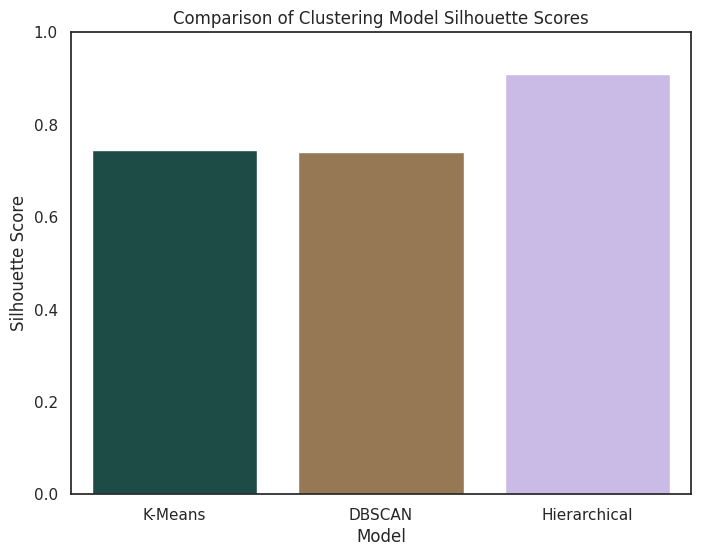

,Model,Silhouette Score
0,K-Means,0.745254
1,DBSCAN,0.739750
2,Hierarchical,0.909958


In [90]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- 1. Data Preparation ---

# Select RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Scale the features using RobustScaler (less sensitive to outliers than StandardScaler)
scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm_features.index)

print("Scaled RFM features head:")
display(rfm_scaled_df.head())

# --- 2. K-Means Clustering ---
print("\n--- K-Means Clustering ---")

# Determine optimal number of clusters (K) using Elbow Method and Silhouette Score
wcss = [] # Within-cluster sum of squares
silhouette_scores = []
max_k = 10

for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)
    labels = kmeans.labels_
    sil_score = silhouette_score(rfm_scaled_df, labels)
    sil_score = np.nan_to_num(sil_score, nan=0.0)
    sil_score = 0.0 if np.isinf(sil_score) else sil_score # Handle potential inf if only 1 cluster is formed by chance
    sil_score = max(0, sil_score) # Ensure non-negative
    sil_score = min(1, sil_score) # Ensure not greater than 1
    sil_score = float(sil_score)
    silhouette_scores.append(sil_score)

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), wcss, marker='o')
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal K (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Choose an optimal K based on plots (e.g., K=3 or K=4 from elbow/silhouette)
# For demonstration, let's pick a K, e.g., 4 or 5
optimal_k_kmeans = 4 # Example: adjust based on visual inspection of plots

kmeans_model = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
rfm_scaled_df['KMeans_Cluster'] = kmeans_model.fit_predict(rfm_scaled_df)
kmeans_silhouette = silhouette_score(rfm_scaled_df.drop('KMeans_Cluster', axis=1), rfm_scaled_df['KMeans_Cluster'])
print(f"K-Means Silhouette Score (K={optimal_k_kmeans}): {kmeans_silhouette:.3f}")

# Visualization for K-Means
plt.figure(figsize=(10, 7))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='KMeans_Cluster', palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k_kmeans}) - Recency vs. Monetary')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.show()

# --- 3. K-Median Clustering ---
print("\n--- K-Median Clustering ---")
print("Note: K-Median clustering is not directly available in scikit-learn.")
print("It uses the Manhattan distance (L1 norm) for centroid calculation, making it more robust to outliers than K-Means.")
print("Implementing it would typically require a specialized library (e.g., 'scikit-learn-extra') or a custom implementation.")
print("For this demonstration, we will proceed with other standard scikit-learn models.")

# --- 4. DBSCAN Clustering ---
print("\n--- DBSCAN Clustering ---")

# DBSCAN requires tuning of eps (maximum distance between two samples for one to be considered as in the neighborhood of the other)
# and min_samples (number of samples in a neighborhood for a point to be considered as a core point).
# These parameters are highly dataset-dependent.

# Example parameters - these may need significant tuning for optimal results
dbscan_model = DBSCAN(eps=0.5, min_samples=5) # Starting point, adjust as needed
rfm_scaled_df['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfm_scaled_df.drop('KMeans_Cluster', axis=1, errors='ignore'))

# DBSCAN can label noise points as -1. Exclude them for silhouette score calculation.
valid_dbscan_indices = rfm_scaled_df['DBSCAN_Cluster'] != -1
if len(set(rfm_scaled_df.loc[valid_dbscan_indices, 'DBSCAN_Cluster'])) > 1: # Ensure more than one cluster (excluding noise)
    dbscan_silhouette = silhouette_score(rfm_scaled_df.loc[valid_dbscan_indices].drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1, errors='ignore'),
                                         rfm_scaled_df.loc[valid_dbscan_indices, 'DBSCAN_Cluster'])
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.3f}")
else:
    dbscan_silhouette = 0.0 # Or NaN if no valid clusters
    print("DBSCAN resulted in 0 or 1 cluster (excluding noise points). Silhouette score cannot be calculated.")

# Visualization for DBSCAN
plt.figure(figsize=(10, 7))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab10', legend='full', alpha=0.7)
plt.title('DBSCAN Clustering - Recency vs. Monetary')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.show()

print(f"DBSCAN found {rfm_scaled_df['DBSCAN_Cluster'].nunique()} clusters (including noise as -1).")

# --- 5. Hierarchical Clustering (AgglomerativeClustering) ---
print("\n--- Hierarchical Clustering ---")

# For consistency, use the same number of clusters as K-Means if determined as optimal
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_k_kmeans, linkage='ward') # 'ward' minimizes variance within clusters
rfm_scaled_df['Hierarchical_Cluster'] = hierarchical_model.fit_predict(rfm_scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster'], axis=1, errors='ignore'))
hierarchical_silhouette = silhouette_score(rfm_scaled_df.drop(['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster'], axis=1, errors='ignore'), rfm_scaled_df['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Silhouette Score (K={optimal_k_kmeans}): {hierarchical_silhouette:.3f}")

# Visualization for Hierarchical Clustering
plt.figure(figsize=(10, 7))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='Hierarchical_Cluster', palette='rainbow', legend='full', alpha=0.7)
plt.title(f'Hierarchical Clustering (K={optimal_k_kmeans}) - Recency vs. Monetary')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.show()

# --- 6. Comparative Evaluation ---
print("\n--- Comparative Evaluation of Clustering Models ---")

silhouette_data = {
    'Model': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette Score': [kmeans_silhouette, dbscan_silhouette, hierarchical_silhouette]
}
silhouette_df = pd.DataFrame(silhouette_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Silhouette Score', data=silhouette_df, palette='cubehelix')
plt.title('Comparison of Clustering Model Silhouette Scores')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette score ranges from -1 to 1, but positive is generally desired
plt.show()

display(silhouette_df)